In [38]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from matplotlib import pyplot
%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

Dispositivo: cpu


In [39]:
df_raw = pd.read_csv('bakery_sales_revised.csv')
df_raw['date_time'] = pd.to_datetime(df_raw['date_time'])
df_raw['fecha_dia'] = df_raw['date_time'].dt.date
df_raw = df_raw[df_raw['period_day'].isin(['morning', 'afternoon'])].copy()

df_raw['Es_Bread']     = df_raw['Item'].apply(lambda x: 1 if 'bread' in str(x).lower() or 'baguette' in str(x).lower() or 'focaccia' in str(x).lower() else 0)
df_raw['Es_Pastry']    = df_raw['Item'].apply(lambda x: 1 if 'pastry' in str(x).lower() or 'croissant' in str(x).lower() or 'scone' in str(x).lower() else 0)
df_raw['Es_Cookies']   = df_raw['Item'].apply(lambda x: 1 if 'cookie' in str(x).lower() else 0)
df_raw['Es_Cake']      = df_raw['Item'].apply(lambda x: 1 if 'cake' in str(x).lower() or 'brownie' in str(x).lower() else 0)
df_raw['Es_Muffin']    = df_raw['Item'].apply(lambda x: 1 if 'muffin' in str(x).lower() else 0)
df_raw['Es_Medialuna'] = df_raw['Item'].apply(lambda x: 1 if 'medialuna' in str(x).lower() or 'alfajor' in str(x).lower() or 'scandinavian' in str(x).lower() else 0)
items_cafe = ['coffee', 'hot chocolate', 'tea', 'juice', 'smoothie']
df_raw['Es_Cafe']      = df_raw['Item'].apply(lambda x: 1 if any(i in str(x).lower() for i in items_cafe) else 0)

df_turno = df_raw.groupby(['fecha_dia', 'period_day']).agg(
    Venta_Cafe     =('Es_Cafe',       'sum'),
    Venta_Bread    =('Es_Bread',      'sum'),
    Venta_Pastry   =('Es_Pastry',     'sum'),
    Venta_Cookies  =('Es_Cookies',    'sum'),
    Venta_Cake     =('Es_Cake',       'sum'),
    Venta_Muffin   =('Es_Muffin',     'sum'),
    Venta_Medialuna=('Es_Medialuna',  'sum')
).reset_index()

df_turno['fecha_dia'] = pd.to_datetime(df_turno['fecha_dia'])

df_turno = df_turno.sort_values(['fecha_dia', 'period_day']).reset_index(drop=True)

df_turno['dia_semana']  = df_turno['fecha_dia'].dt.weekday   
df_turno['mes']         = df_turno['fecha_dia'].dt.month
df_turno['dia_mes']     = df_turno['fecha_dia'].dt.day
df_turno['turno']       = (df_turno['period_day'] == 'morning').astype(int)
df_turno['es_finde']    = (df_turno['dia_semana'] >= 5).astype(int)

df_turno['dia_sin'] = np.sin(2 * np.pi * df_turno['dia_semana'] / 7)
df_turno['dia_cos'] = np.cos(2 * np.pi * df_turno['dia_semana'] / 7)
df_turno['mes_sin'] = np.sin(2 * np.pi * df_turno['mes'] / 12)
df_turno['mes_cos'] = np.cos(2 * np.pi * df_turno['mes'] / 12)

df_diario = df_turno.copy()
print(df_diario[['fecha_dia', 'period_day', 'turno', 'Venta_Cafe', 'Venta_Bread', 'dia_sin', 'dia_cos']].head(8))

   fecha_dia period_day  turno  Venta_Cafe  Venta_Bread   dia_sin   dia_cos
0 2016-10-30  afternoon      0          33            9 -0.781831  0.623490
1 2016-10-30    morning      1          20           20 -0.781831  0.623490
2 2016-10-31  afternoon      0          36            9  0.000000  1.000000
3 2016-10-31    morning      1          47           13  0.000000  1.000000
4 2016-11-01  afternoon      0          36           12  0.781831  0.623490
5 2016-11-01    morning      1          25            9  0.781831  0.623490
6 2016-11-02  afternoon      0          31            5  0.974928 -0.222521
7 2016-11-02    morning      1          31           12  0.974928 -0.222521


In [ ]:
features_kmeans = ['Venta_Cafe', 'Venta_Bread', 'Venta_Pastry',
                   'Venta_Cookies', 'Venta_Cake', 'Venta_Muffin', 'Venta_Medialuna']

n_total   = len(df_diario)
split_idx = int(n_total * 0.8)          

X_kmeans_all = df_diario[features_kmeans].values

scaler_kmeans = StandardScaler()
scaler_kmeans.fit(X_kmeans_all[:split_idx])           
X_kmeans_scaled = scaler_kmeans.transform(X_kmeans_all)  
inercias    = []
silhouettes = []
rango_k     = range(2, 7)

for k in rango_k:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    etq = km.fit_predict(X_kmeans_scaled[:split_idx])   
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_kmeans_scaled[:split_idx], etq))

mejor_k = list(rango_k)[silhouettes.index(max(silhouettes))]
print(f"Mejor k según Silhouette: {mejor_k}  |  Score máximo: {max(silhouettes):.4f}")

kmeans = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
kmeans.fit(X_kmeans_scaled[:split_idx])              
df_diario['demanda'] = kmeans.predict(X_kmeans_scaled)  


Mejor k según Silhouette: 2  |  Score máximo: 0.2906


In [41]:
X_raw = df_diario[['dia_sin', 'dia_cos', 'mes_sin', 'mes_cos',
                    'turno', 'es_finde', 'demanda']].values.astype(np.float32)
y_raw = df_diario[['Venta_Cafe', 'Venta_Bread', 'Venta_Pastry',
                   'Venta_Cookies', 'Venta_Cake', 'Venta_Muffin', 'Venta_Medialuna']].values.astype(np.float32)

X_min = X_raw[:split_idx].min(axis=0)
X_max = X_raw[:split_idx].max(axis=0)
y_min = y_raw[:split_idx].min(axis=0)
y_max = y_raw[:split_idx].max(axis=0)

X_scaled = (X_raw - X_min) / (X_max - X_min + 1e-8)
y_scaled = (y_raw - y_min) / (y_max - y_min + 1e-8)

X_train, X_val = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_val = y_scaled[:split_idx], y_scaled[split_idx:]

print(f"Train: {len(X_train)} turnos | Validacion: {len(X_val)} turnos")
print(f"Features de entrada: {X_raw.shape[1]}")
print(f"Fecha de corte train/val: {df_diario.iloc[split_idx]['fecha_dia'].date()}")

Train: 253 turnos | Validacion: 64 turnos
Features de entrada: 7
Fecha de corte train/val: 2017-03-09


In [43]:
class modelocafe(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.capa1       = nn.Linear(input_dim, 16)
        self.relu1       = nn.ReLU()
        self.dropout1    = nn.Dropout(0.2)
        self.capa2       = nn.Linear(16, 8)
        self.relu2       = nn.ReLU()
        self.capa_salida = nn.Linear(8, output_dim)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.capa1(x)))
        x = self.relu2(self.capa2(x))
        return self.capa_salida(x)

def cargar_modelo(config):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model  = modelocafe(config['input_dim'], config['output_dim']).to(device)
    model.load_state_dict(
        torch.load('checkpoint_cafeteria.pt',
                   map_location=device, weights_only=True)
    )
    model.eval()
    return model, device

In [42]:
class CafeteriaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CafeteriaDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader   = DataLoader(CafeteriaDataset(X_val,   y_val),   batch_size=16, shuffle=False)

In [44]:

def evaluate(model, loader):
    model.eval()
    criterio = nn.L1Loss()
    losses = []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            pred = model(x_b)
            losses.append(criterio(pred, y_b).item())
    return np.mean(losses)

def fit(model, train_loader, val_loader, epochs=600, PATH="./checkpoint_cafeteria.pt"):
    optimizer     = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-5)
    criterion     = nn.L1Loss()   
    best_val_loss = float('inf')
    historial_train = []
    historial_val   = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_b), y_b)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        epoch_loss = np.mean(losses)
        val_loss   = evaluate(model, val_loader)
        historial_train.append(epoch_loss)
        historial_val.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), PATH)
            print(f"Checkpoint guardado en Época {epoch}/{epochs} -> [Mejor Val Loss: {val_loss:.5f}]")

        if epoch % 100 == 0:
            print(f"-> Época {epoch}/{epochs}  Train Loss: {epoch_loss:.5f}  Val Loss: {val_loss:.5f}  (Mejor: {best_val_loss:.5f})")

    model.load_state_dict(torch.load(PATH, weights_only=True)) 
    print(f"Modelo restaurado. Mejor Val Loss: {best_val_loss:.5f}")
    return historial_train, historial_val

model = modelocafe(input_dim=X_train.shape[1], output_dim=y_train.shape[1]).to(device)
print(model)
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print(f"input_dim={X_train.shape[1]} | output_dim={y_train.shape[1]}")

historial_train, historial_val = fit(model, train_loader, val_loader,
                                     epochs=600, PATH="./checkpoint_cafeteria.pt")

modelocafe(
  (capa1): Linear(in_features=7, out_features=16, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (capa2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (capa_salida): Linear(in_features=8, out_features=7, bias=True)
)
Parámetros totales: 327
input_dim=7 | output_dim=7
Checkpoint guardado en Época 1/600 -> [Mejor Val Loss: 0.17108]
Checkpoint guardado en Época 2/600 -> [Mejor Val Loss: 0.13987]
Checkpoint guardado en Época 3/600 -> [Mejor Val Loss: 0.12000]
Checkpoint guardado en Época 4/600 -> [Mejor Val Loss: 0.11653]
Checkpoint guardado en Época 5/600 -> [Mejor Val Loss: 0.11509]
Checkpoint guardado en Época 6/600 -> [Mejor Val Loss: 0.11138]
Checkpoint guardado en Época 7/600 -> [Mejor Val Loss: 0.11004]
Checkpoint guardado en Época 8/600 -> [Mejor Val Loss: 0.10893]
Checkpoint guardado en Época 10/600 -> [Mejor Val Loss: 0.10752]
Checkpoint guardado en Época 13/600 -> [Mejor Val Loss: 0.10631]
Checkpoint guardado en Ép

In [45]:
from datetime import datetime
perfiles_referencia = (
    df_diario.iloc[:split_idx]                         
    .groupby(['dia_semana', 'turno'])[features_kmeans]
    .mean()
)

def predecir_produccion(fecha_str, turno_str):
    fecha_obj  = datetime.strptime(fecha_str, "%Y-%m-%d")
    dia_semana = fecha_obj.weekday()        
    mes        = fecha_obj.month
    turno      = 1 if turno_str == 'morning' else 0
    es_finde   = 1 if dia_semana >= 5 else 0

    # Encoding cíclico 
    dia_sin = np.sin(2 * np.pi * dia_semana / 7)
    dia_cos = np.cos(2 * np.pi * dia_semana / 7)
    mes_sin = np.sin(2 * np.pi * mes / 12)
    mes_cos = np.cos(2 * np.pi * mes / 12)

    if (dia_semana, turno) in perfiles_referencia.index:
        perfil = perfiles_referencia.loc[(dia_semana, turno)].values.reshape(1, -1)
    else:
        perfil = df_diario.iloc[:split_idx][df_diario.iloc[:split_idx]['turno'] == turno][features_kmeans].mean().values.reshape(1, -1)

    perfil_scaled    = scaler_kmeans.transform(perfil)
    cluster_asignado = kmeans.predict(perfil_scaled)[0]

    vector_entrada = np.array([[dia_sin, dia_cos, mes_sin, mes_cos,
                                 turno, es_finde, cluster_asignado]],
                               dtype=np.float32)

    vector_scaled  = (vector_entrada - X_min) / (X_max - X_min + 1e-8)
    tensor_entrada = torch.tensor(vector_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(tensor_entrada).cpu().numpy()[0]

    pred_real = (pred_scaled * (y_max - y_min + 1e-8)) + y_min

    nombres_menu = [
        'Cafés y Bebidas     ',
        'Panes / Baguettes   ',
        'Masas / Croissants  ',
        'Galletas / Cookies  ',
        'Tortas / Porciones  ',
        'Muffins / Magdalenas',
        'Medialunas / Alfajores'
    ]

    proyeccion = {prod: max(0, int(np.round(pred_real[i])))
                  for i, prod in enumerate(nombres_menu)}
    return proyeccion, dia_semana, cluster_asignado

fechas_prueba = ["2026-06-11", "2026-06-14", "2026-06-17"]
turnos_prueba = ["morning", "afternoon"]
dias_nombre   = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

print("PLAN DE PRODUCCIÓN — 7 PRODUCTOS x TURNO")

for fecha in fechas_prueba:
    for turno in turnos_prueba:
        inventario, cod_dia, clus = predecir_produccion(fecha, turno)
        print(f"  {fecha} ({dias_nombre[cod_dia]}) — {turno.upper()}  [Cluster={clus}]")
        print("-" * 70)
        for item, cantidad in inventario.items():
            print(f"    {item}: {cantidad} unidades")
        print()

PLAN DE PRODUCCIÓN — 7 PRODUCTOS x TURNO
  2026-06-11 (Jueves) — MORNING  [Cluster=0]
----------------------------------------------------------------------
    Cafés y Bebidas     : 23 unidades
    Panes / Baguettes   : 11 unidades
    Masas / Croissants  : 5 unidades
    Galletas / Cookies  : 1 unidades
    Tortas / Porciones  : 4 unidades
    Muffins / Magdalenas: 0 unidades
    Medialunas / Alfajores: 3 unidades

  2026-06-11 (Jueves) — AFTERNOON  [Cluster=0]
----------------------------------------------------------------------
    Cafés y Bebidas     : 28 unidades
    Panes / Baguettes   : 10 unidades
    Masas / Croissants  : 3 unidades
    Galletas / Cookies  : 2 unidades
    Tortas / Porciones  : 7 unidades
    Muffins / Magdalenas: 0 unidades
    Medialunas / Alfajores: 3 unidades

  2026-06-14 (Domingo) — MORNING  [Cluster=0]
----------------------------------------------------------------------
    Cafés y Bebidas     : 26 unidades
    Panes / Baguettes   : 13 unidades
    

MÉTRICAS SOBRE DATOS NO VISTOS (Set de Validación — por turno)
  Cafés y Bebidas           : MAE =   4.8 uds  ████
  Panes / Baguettes         : MAE =   2.7 uds  ██
  Masas / Croissants        : MAE =   1.9 uds  █
  Galletas / Cookies        : MAE =   1.3 uds  █
  Tortas / Porciones        : MAE =   2.3 uds  ██
  Muffins / Magdalenas      : MAE =   1.1 uds  █
  Medialunas / Alfajores    : MAE =   1.8 uds  █
------------------------------------------------------------
  MAE promedio global       : 2.3 unidades/turno
MAE = error promedio por turno en unidades REALES de producto


C:\Users\usuario\AppData\Local\Temp\ipykernel_1088\2728907448.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pyplot.tight_layout()


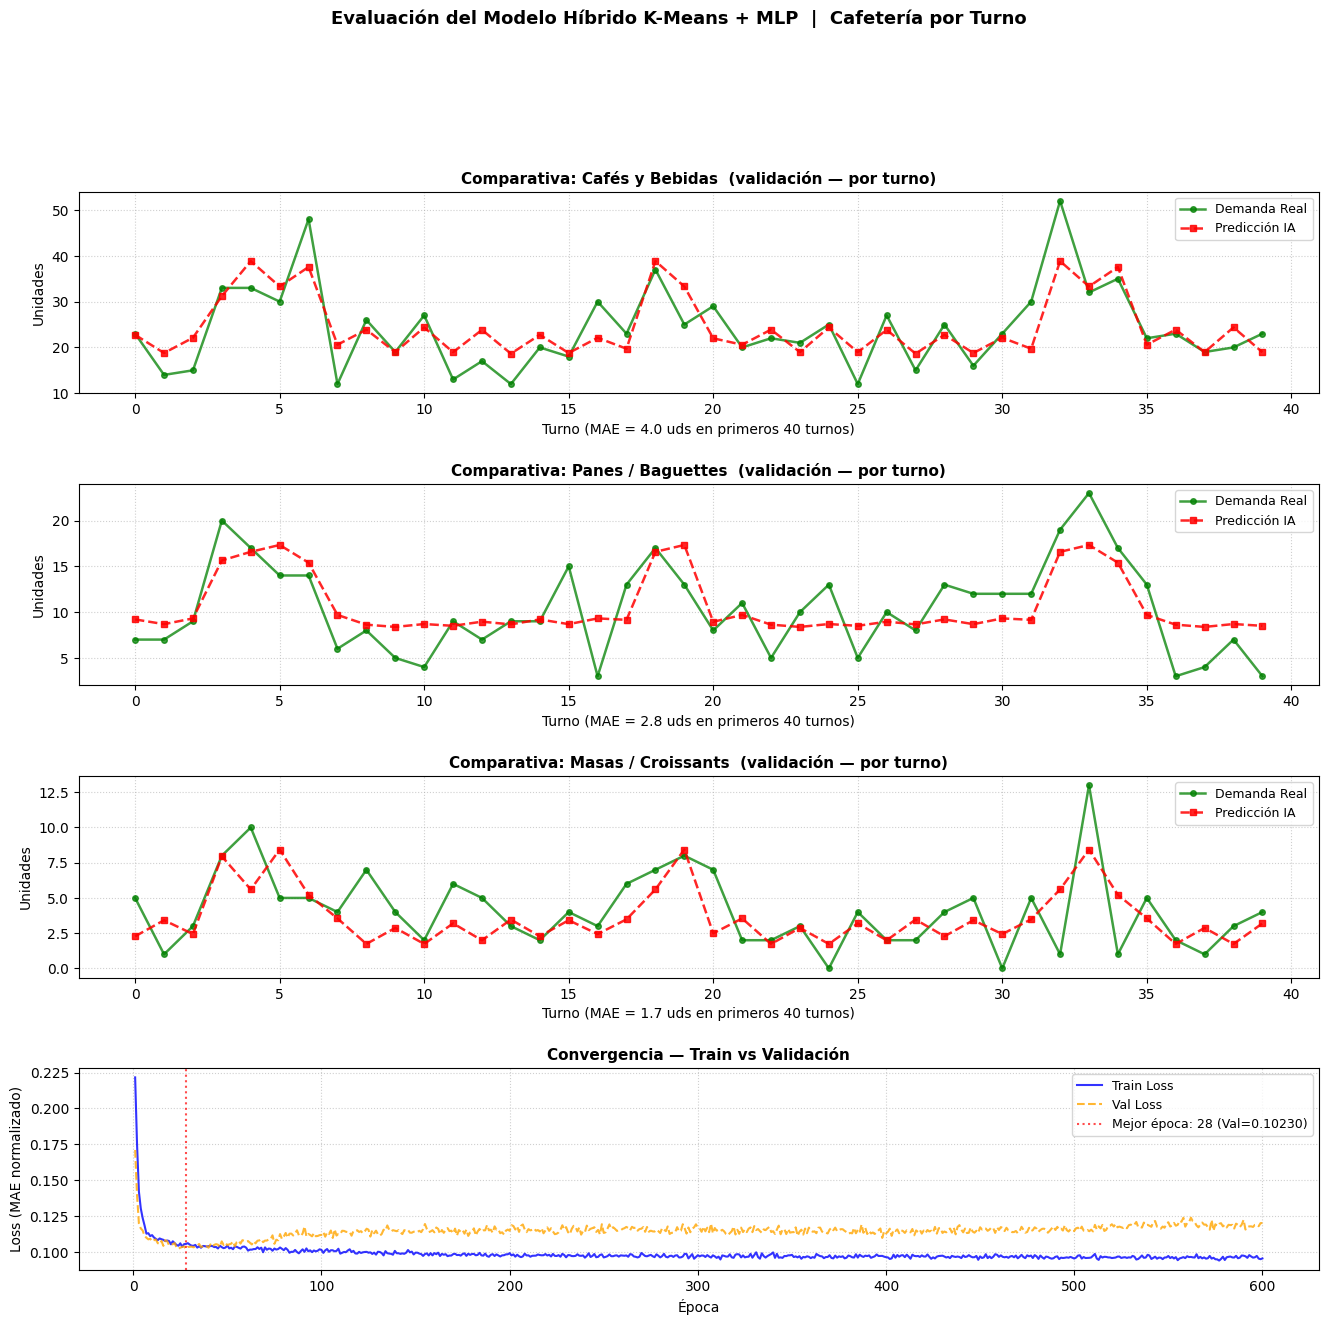

In [46]:
import matplotlib.gridspec as gridspec

nombres_productos = [
    'Cafés y Bebidas', 'Panes / Baguettes', 'Masas / Croissants',
    'Galletas / Cookies', 'Tortas / Porciones', 'Muffins / Magdalenas', 
    'Medialunas / Alfajores'
]

model.eval()
with torch.no_grad():
    pred_val_scaled = model(
        torch.tensor(X_val, dtype=torch.float32).to(device)
    ).cpu().numpy()

pred_val_real = (pred_val_scaled * (y_max - y_min + 1e-8)) + y_min
real_val      = (y_val          * (y_max - y_min + 1e-8)) + y_min

print("MÉTRICAS SOBRE DATOS NO VISTOS (Set de Validación — por turno)")
mae_total = 0
for idx, prod in enumerate(nombres_productos):
    mae = np.mean(np.abs(real_val[:, idx] - pred_val_real[:, idx]))
    mae_total += mae
    barra = "█" * int(mae)
    print(f"  {prod.ljust(26)}: MAE = {mae:5.1f} uds  {barra}")
print("-" * 60)
print(f"  {'MAE promedio global'.ljust(26)}: {mae_total / len(nombres_productos):.1f} unidades/turno")
print("=" * 60)
print("MAE = error promedio por turno en unidades REALES de producto")

fig = pyplot.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

rango_dias = min(40, len(real_val))

for idx, prod in enumerate(nombres_productos[:3]):
    ax = fig.add_subplot(gs[idx])
    ax.plot(real_val[:rango_dias, idx],      'g-o',  
            label='Demanda Real',  alpha=0.75, linewidth=1.8, markersize=4)
    ax.plot(pred_val_real[:rango_dias, idx], 'r--s', 
            label='Predicción IA', alpha=0.85, linewidth=1.8, markersize=4)
    ax.set_title(f"Comparativa: {prod}  (validación — por turno)", 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel("Unidades")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9)

    mae_prod = np.mean(np.abs(real_val[:rango_dias, idx] - pred_val_real[:rango_dias, idx]))
    ax.set_xlabel(f"Turno (MAE = {mae_prod:.1f} uds en primeros {rango_dias} turnos)")

ax_loss = fig.add_subplot(gs[3])
epocas_eje = np.arange(1, len(historial_train) + 1)
ax_loss.plot(epocas_eje, historial_train, 'b-',           
             alpha=0.8, linewidth=1.5, label='Train Loss')
ax_loss.plot(epocas_eje, historial_val,   color='orange', 
             alpha=0.8, linewidth=1.5, linestyle='--', label='Val Loss')

mejor_epoch = np.argmin(historial_val) + 1
mejor_loss  = min(historial_val)
ax_loss.axvline(x=mejor_epoch, color='red', linestyle=':', alpha=0.7,
                label=f'Mejor época: {mejor_epoch} (Val={mejor_loss:.5f})')

ax_loss.set_xlabel("Época")
ax_loss.set_ylabel("Loss (MAE normalizado)")
ax_loss.set_title("Convergencia — Train vs Validación", 
                  fontsize=11, fontweight='bold')
ax_loss.grid(True, linestyle=':', alpha=0.6)
ax_loss.legend(fontsize=9)

pyplot.suptitle(
    "Evaluación del Modelo Híbrido K-Means + MLP  |  Cafetería por Turno",
    fontsize=13, fontweight='bold', y=1.01
)
pyplot.tight_layout()
pyplot.show()

In [47]:
import pickle
import json

print(f"Checkpoint del modelo: ./checkpoint_cafeteria.pt")
with open('scaler_kmeans.pkl', 'wb') as f:
    pickle.dump(scaler_kmeans, f)
print(f"scaler_kmeans.pkl guardado")
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print(f"kmeans_model.pkl guardado  (k={mejor_k})")

norm_params = {
    'X_min': X_min.tolist(),
    'X_max': X_max.tolist(),
    'y_min': y_min.tolist(),
    'y_max': y_max.tolist(),
}
with open('norm_params.json', 'w') as f:
    json.dump(norm_params, f)
print(f" norm_params.json guardado")

perfiles_dict = {
    str(k): {feat: float(v[feat]) for feat in features_kmeans}
    for k, v in perfiles_referencia.to_dict('index').items()
}
with open('perfiles_referencia.json', 'w') as f:
    json.dump(perfiles_dict, f)
print(f"perfiles_referencia.json guardado  ({len(perfiles_dict)} perfiles)")

val_data = {
    'real':      real_val.tolist(),
    'predicho':  pred_val_real.tolist(),
    'nombres':   nombres_productos,
    'mejor_k':   int(mejor_k),
    'mae_global': float(np.mean([
        np.mean(np.abs(real_val[:, i] - pred_val_real[:, i]))
        for i in range(len(nombres_productos))
    ]))
}
with open('val_data.json', 'w') as f:
    json.dump(val_data, f)
print(f"val_data.json guardado")

config = {
    'input_dim':          int(X_train.shape[1]),
    'output_dim':         int(y_train.shape[1]),
    'features_kmeans':    features_kmeans,
    'nombres_productos':  nombres_productos,
    'mejor_k':            int(mejor_k),
}
with open('model_config.json', 'w') as f:
    json.dump(config, f)
print(f"model_config.json guardado")
torch.save(model, 'modelo_completo.pt')



Checkpoint del modelo: ./checkpoint_cafeteria.pt
scaler_kmeans.pkl guardado
kmeans_model.pkl guardado  (k=2)
 norm_params.json guardado
perfiles_referencia.json guardado  (14 perfiles)
val_data.json guardado
model_config.json guardado
